# Multiple Linear Regression Demo 

**Goal:** Predict **House Price** based on **several** features:
- `area_sqft`
- `bedrooms`
- `age_years`
- `distance_to_city_km`

This is called **multiple regression** because there is **more than one input feature** used to predict a continuous number (price).

We will use `house_prices.csv` (make sure it's in the same folder as this notebook).

## Step 1: Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load the dataset

In [2]:
df = pd.read_csv('house_prices.csv')
df.head()

,area_sqft,bedrooms,age_years,distance_to_city_km,price
0,671.0,4,34.0,4.7,130309.0
1,1512.0,1,19.0,17.7,196170.0
2,3023.0,1,28.0,10.3,351774.0
3,576.0,4,4.0,12.7,165852.0
4,1221.0,5,15.0,22.3,185089.0


In [3]:
df.describe()

,area_sqft,bedrooms,age_years,distance_to_city_km,price
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2322.960000,3.060000,20.490000,15.033000,311168.740000
std,956.873855,1.301281,11.526426,8.496809,114864.894497
min,576.000000,1.000000,0.000000,0.600000,99018.000000
25%,1536.750000,2.000000,10.000000,8.575000,207372.500000
50%,2298.500000,3.000000,21.000000,13.500000,302959.500000
75%,3267.750000,4.000000,30.000000,22.000000,422503.000000
max,3897.000000,5.000000,40.000000,29.600000,492214.000000


## Step 3: Split data into features (X) and target (y)

This time `X` has **4 columns** instead of just 1.

In [4]:
X = df[['area_sqft', 'bedrooms', 'age_years', 'distance_to_city_km']]
y = df['price']

## Step 4: Split into training and testing sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 80
Testing samples: 20


## Step 5: Train a Linear Regression model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept:', round(model.intercept_, 2))
print('\nCoefficients (impact of each feature on price):')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature}: {coef:.2f}')

Intercept: 41851.8

Coefficients (impact of each feature on price):
  area_sqft: 118.46
  bedrooms: 9919.77
  age_years: -858.84
  distance_to_city_km: -1178.05


Each coefficient tells you how much `price` changes when that feature increases by 1 unit, **holding all other features constant**. For example, a positive `area_sqft` coefficient means bigger houses tend to cost more.

## Step 6: Make predictions on the test set

In [7]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred.round(2)})
comparison.head(10)

,actual,predicted
0,241731.0,249795.12
1,445158.0,443583.69
2,187724.0,181198.28
3,294724.0,284209.95
4,477891.0,490374.77
5,363330.0,378172.28
6,218541.0,213382.14
7,436293.0,432692.69
8,103536.0,131297.02
9,130309.0,126276.89


## Step 7: Visualize predicted vs actual

With multiple features we can't plot a single best-fit line like before, so instead we plot **predicted vs actual** values. Points close to the diagonal line mean good predictions.

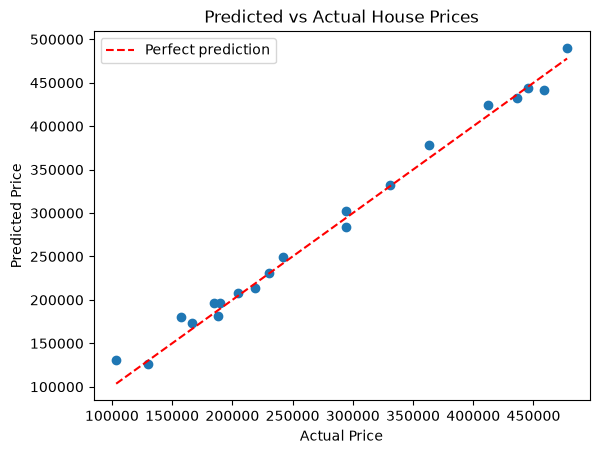

In [8]:
plt.scatter(y_test, y_pred)
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual House Prices')
plt.legend()
plt.show()

## Step 8: Evaluate the model

In [9]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 score: {r2:.2f}')

MAE:  9284.47
RMSE: 11580.61
R2 score: 0.99


## Step 9: Predict the price of a new house

Try changing the numbers below and re-running to see how the predicted price changes.

In [10]:
new_house = pd.DataFrame({
    'area_sqft': [2200],
    'bedrooms': [3],
    'age_years': [10],
    'distance_to_city_km': [8]
})

predicted_price = model.predict(new_house)[0]
print(f'Predicted price: {predicted_price:.2f}')

Predicted price: 314200.02


### Summary
- **Multiple regression** = predicting a **number** using **two or more** input features.
- We used the same `LinearRegression` class as simple regression — it automatically handles multiple columns.
- Same evaluation metrics as simple regression: **MAE**, **RMSE**, **R²**.
- Since we can't plot a single line with 4 features, we used a **predicted vs actual** scatter plot instead.